# Objective

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Dataset Overview

In [4]:
df = pd.read_csv(
    "../data/processed/cleaned_retail_data.csv"
)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1,Tuesday,0,Winter,112,2017.2,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,445,2017.2,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,358,2017.2,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1,Tuesday,0,Winter,280,2017.2,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1,Tuesday,0,Winter,116,2017.2,1


In [6]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [7]:
daily_sales = df.groupby(
    df["InvoiceDate"].dt.date
)["TotalSales"].sum().reset_index()

In [8]:
daily_sales.columns = [
    "Date",
    "Sales"
]

In [9]:
daily_sales.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [10]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_retail_data.csv"
)

# Feature Engineering

In [11]:
df = df.sort_values("InvoiceDate")

df["Lag_1"] = df["TotalSales"].shift(1)
df["Lag_7"] = df["TotalSales"].shift(7)
df["Lag_14"] = df["TotalSales"].shift(14)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason,Lag_1,Lag_7,Lag_14
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1,Tuesday,0,Winter,112,2017.2,1,NaN,NaN,NaN
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,445,2017.2,1,83.4,NaN,NaN
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,358,2017.2,1,81.0,NaN,NaN
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1,Tuesday,0,Winter,280,2017.2,1,81.0,NaN,NaN
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1,Tuesday,0,Winter,116,2017.2,1,100.8,NaN,NaN


In [12]:
df["Rolling_Mean_7"] = df["TotalSales"].rolling(7).mean()
df["Rolling_Std_7"] = df["TotalSales"].rolling(7).std()

In [13]:
df = df.dropna()
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason,Lag_1,Lag_7,Lag_14,Rolling_Mean_7,Rolling_Std_7
14,489436,21754,HOME BUILDING BLOCK WORD,3,2009-12-01 09:06:00,5.95,13078.0,United Kingdom,17.85,2009,12,1,9,1,Tuesday,0,Winter,97,16904.51,1,98.10,59.5,83.4,45.892857,26.474145
15,489436,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2009-12-01 09:06:00,1.69,13078.0,United Kingdom,27.04,2009,12,1,9,1,Tuesday,0,Winter,382,16904.51,1,17.85,30.6,81.0,45.384286,26.848434
16,489436,22119,PEACE WOODEN BLOCK LETTERS,3,2009-12-01 09:06:00,6.95,13078.0,United Kingdom,20.85,2009,12,1,9,1,Tuesday,0,Winter,109,16904.51,1,27.04,45.0,81.0,41.934286,28.412135
17,489436,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-01 09:06:00,1.45,13078.0,United Kingdom,17.40,2009,12,1,9,1,Tuesday,0,Winter,369,16904.51,1,20.85,39.6,100.8,38.762857,29.915361
18,489436,22296,HEART IVORY TRELLIS LARGE,12,2009-12-01 09:06:00,1.65,13078.0,United Kingdom,19.80,2009,12,1,9,1,Tuesday,0,Winter,161,16904.51,1,17.40,30.6,30.0,37.220000,30.675364


In [14]:
df.to_csv("../data/processed/final_features.csv", index=False)

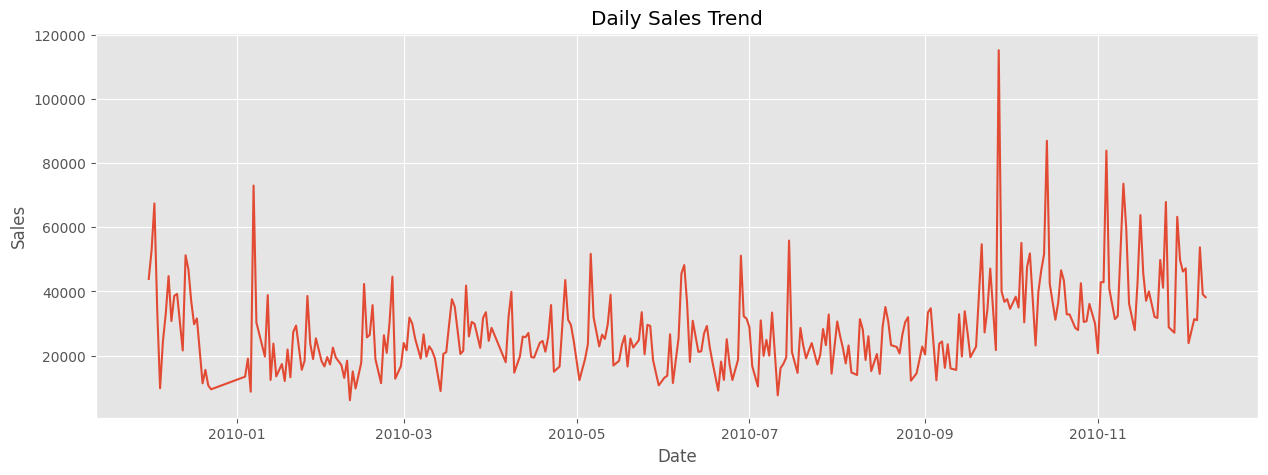

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [16]:
daily_sales["TimeIndex"] = np.arange(
    len(daily_sales)
)

In [17]:
X = daily_sales[["TimeIndex"]]

y = daily_sales["Sales"]

# Model Training

In [18]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
daily_sales["PredictedSales"] = model.predict(X)

In [20]:
import joblib

joblib.dump(
    model,
    "../models/forecast_model.pkl"
)

print("Forecast model saved successfully")

Forecast model saved successfully


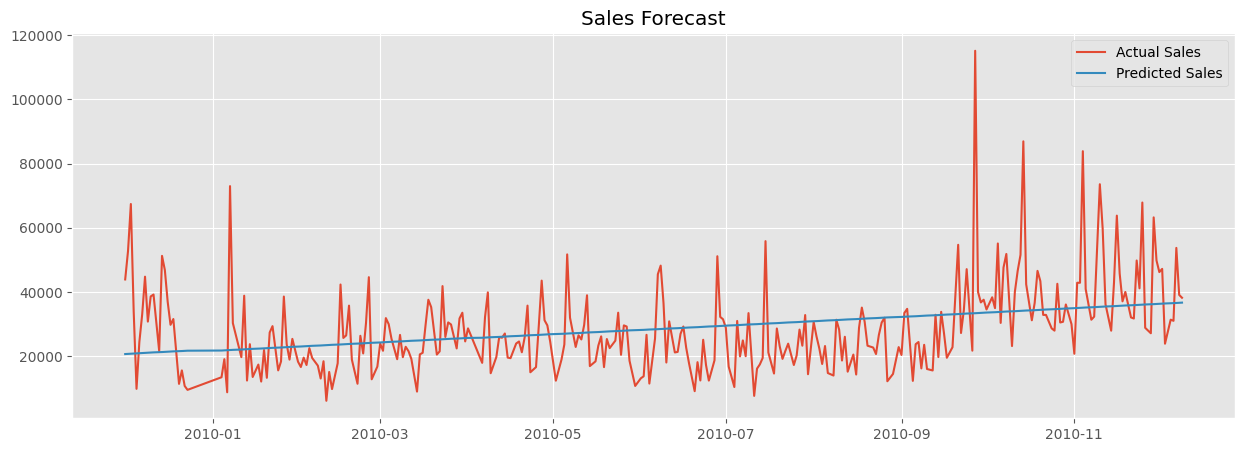

In [21]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    label="Actual Sales"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["PredictedSales"],
    label="Predicted Sales"
)

plt.legend()

plt.title("Sales Forecast")

plt.show()

In [22]:
future_days = pd.DataFrame({

    "TimeIndex": np.arange(
        len(daily_sales),
        len(daily_sales) + 30
    )

})

future_predictions = model.predict(
    future_days
)

In [23]:
future_predictions

array([36725.54220872, 36777.92402932, 36830.30584991, 36882.68767051,
       36935.0694911 , 36987.4513117 , 37039.83313229, 37092.21495289,
       37144.59677348, 37196.97859408, 37249.36041467, 37301.74223527,
       37354.12405586, 37406.50587646, 37458.88769705, 37511.26951765,
       37563.65133824, 37616.03315884, 37668.41497943, 37720.79680002,
       37773.17862062, 37825.56044121, 37877.94226181, 37930.3240824 ,
       37982.705903  , 38035.08772359, 38087.46954419, 38139.85136478,
       38192.23318538, 38244.61500597])

# Conclusion

In [24]:
daily_sales.to_csv(
    "../data/processed/forecast_data.csv",
    index=False
)

In [26]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalSales', 'Year', 'Month', 'Day',
       'Hour', 'DayOfWeek', 'DayName', 'IsWeekend', 'Season', 'InventoryLevel',
       'CustomerTotalSales', 'HolidaySeason', 'Lag_1', 'Lag_7', 'Lag_14',
       'Rolling_Mean_7', 'Rolling_Std_7'],
      dtype='str')


In [27]:
print(daily_sales.columns)

Index(['Date', 'Sales', 'TimeIndex', 'PredictedSales'], dtype='str')
